# Exploración del Dataset — AI4I 2020 Predictive Maintenance

El objetivo es conocer el dataset antes de construir cualquier pipeline. No se toma ninguna decisión de modelado sin entender primero los datos.

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI)  
**Registros:** ~10.000  
**Problema:** Clasificación binaria — predecir si una máquina industrial va a fallar

---

## 1. Setup e importaciones

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Cargar el dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 10000 filas, 14 columnas


---

## 2. Estructura del dataset

Antes de cualquier análisis, entendemos qué hay en cada columna y qué tipo de dato tiene.

In [2]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [3]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

**Descripción de columnas:**

| Columna | Tipo | Descripción |
|---|---|---|
| UDI | int | Identificador único de registro |
| Product ID | str | Código del producto (incluye el tipo) |
| Type | str | Categoría de la máquina: L (low), M (medium), H (high) quality |
| Air temperature [K] | float | Temperatura del aire en Kelvin |
| Process temperature [K] | float | Temperatura del proceso en Kelvin |
| Rotational speed [rpm] | int | Velocidad de rotación en RPM |
| Torque [Nm] | float | Torque aplicado en Newton-metro |
| Tool wear [min] | int | Minutos de uso acumulado de la herramienta |
| Machine failure | int | **Target**: 1 = falla, 0 = no falla |
| TWF | int | Tool Wear Failure |
| HDF | int | Heat Dissipation Failure |
| PWF | int | Power Failure |
| OSF | int | Overstrain Failure |
| RNF | int | Random Failure |

Las columnas `TWF`, `HDF`, `PWF`, `OSF`, `RNF` son subtipos de falla — detallan **por qué** falló la máquina cuando `Machine failure = 1`.

---

## 3. Calidad de los datos — valores nulos

Un dataset con valores nulos requiere estrategias de imputación antes del modelado. Verificamos si este es el caso.

In [4]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos — dataset completo.")

Valores nulos por columna:
Sin valores nulos — dataset completo.


**Conclusión:** El dataset está completo. No se requiere imputación de datos faltantes.

---

## 4. Distribución del target — desbalance de clases

En problemas de clasificación, el desbalance entre clases afecta directamente qué métricas tienen sentido usar para evaluar el modelo.

In [5]:
conteo = df["Machine failure"].value_counts()
porcentaje = df["Machine failure"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({"Conteo": conteo, "Porcentaje": porcentaje.round(2)})
resumen.index = ["No falla (0)", "Falla (1)"]
print(resumen)

              Conteo  Porcentaje
No falla (0)    9661       96.61
Falla (1)        339        3.39


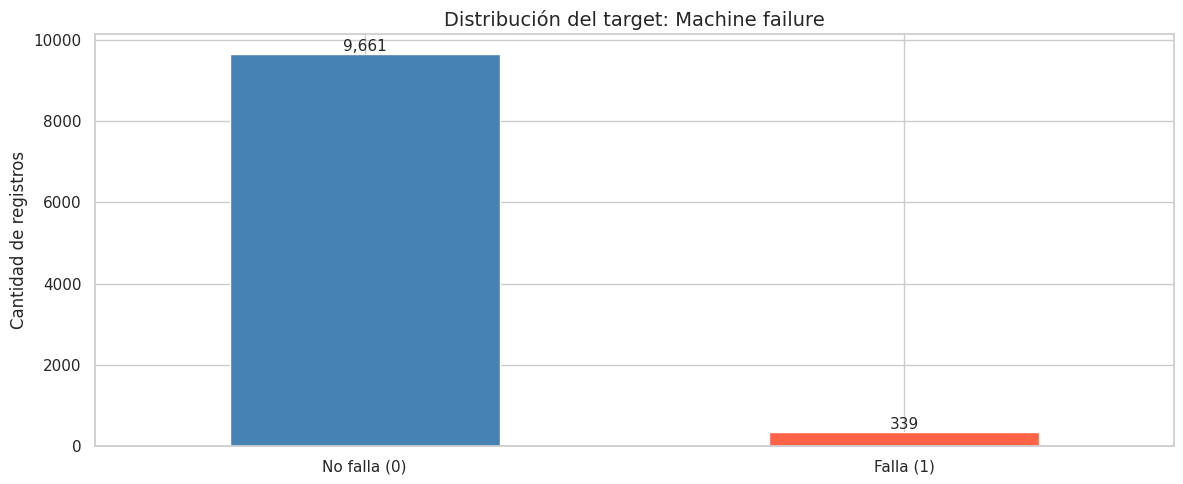

In [6]:
fig, ax = plt.subplots()
conteo.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Distribución del target: Machine failure", fontsize=14)
ax.set_xlabel("")
ax.set_xticklabels(["No falla (0)", "Falla (1)"], rotation=0)
ax.set_ylabel("Cantidad de registros")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
    )
plt.tight_layout()
plt.show()

**Conclusión:** El dataset está fuertemente desbalanceado (~97% no-falla, ~3% falla).

Esto tiene una implicación directa en la elección de métricas:
- Un modelo que predice **siempre "no falla"** tendría ~97% de accuracy — pero sería completamente inútil.
- Por eso usamos **F1-score**, que balancea precision y recall y penaliza al modelo cuando ignora la clase minoritaria (fallas).
- En particular, **recall** es crítico acá: preferimos falsas alarmas a dejar pasar una falla real.

---

## 5. Distribución de las features numéricas

Analizamos la distribución de los sensores para detectar outliers y entender los rangos operativos normales.

In [7]:
features_sensores = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df[features_sensores].describe().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


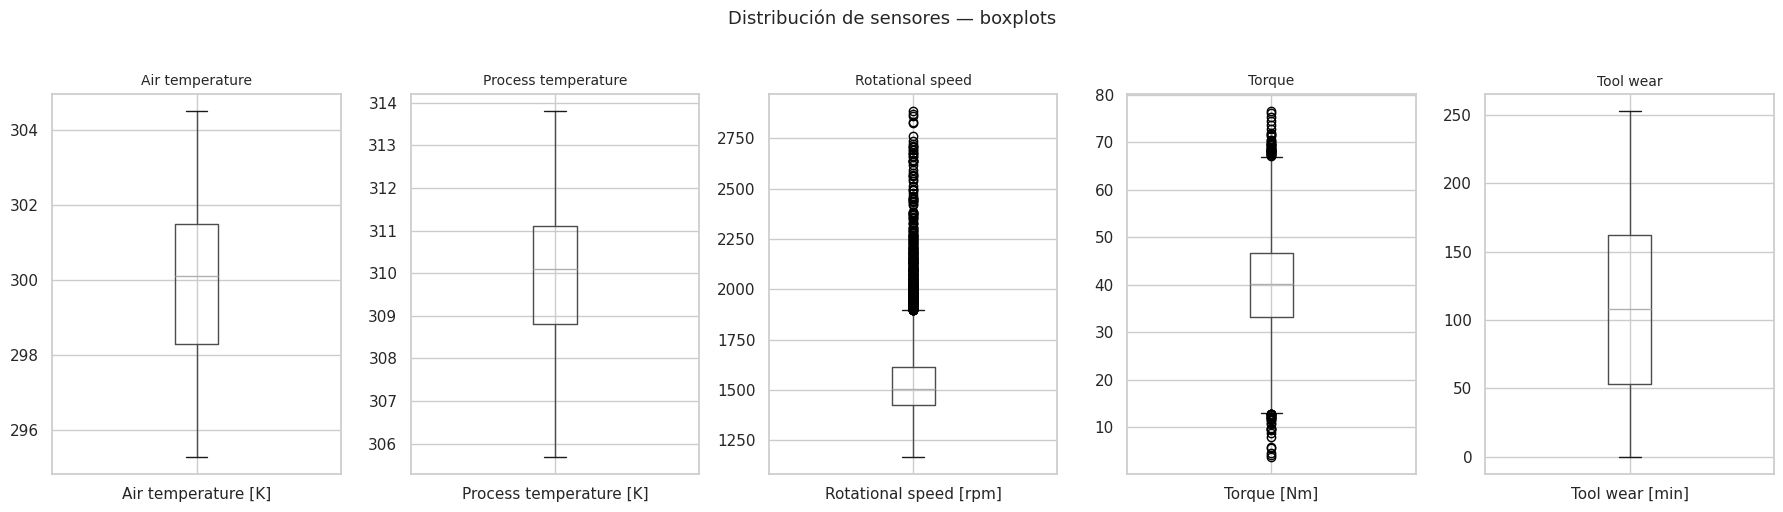

In [8]:
fig, axes = plt.subplots(1, len(features_sensores), figsize=(18, 5))

for ax, col in zip(axes, features_sensores):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col.split(" [")[0], fontsize=10)
    ax.set_xlabel("")

plt.suptitle("Distribución de sensores — boxplots", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación del boxplot:**
- La caja central representa el 50% de los datos (percentil 25 a 75)
- Los bigotes llegan hasta 1.5x el rango intercuartil
- Los puntos fuera de los bigotes son outliers

**Conclusión:** `Rotational speed` y `Torque` presentan outliers visibles. Esto es esperado en datos industriales — condiciones extremas de operación suelen preceder fallas.

---

## 6. Tipos de falla — frecuencia

Cuando una máquina falla, el dataset registra el tipo de falla. Analizamos cuál es el más frecuente.

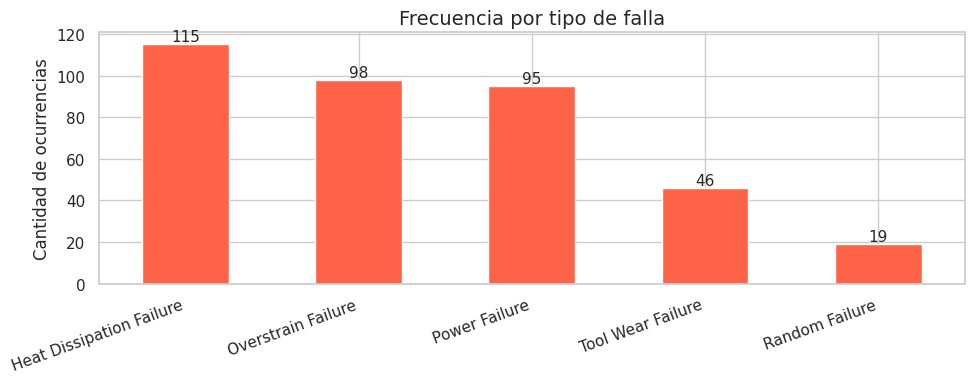

In [9]:
tipos_falla = ["TWF", "HDF", "PWF", "OSF", "RNF"]
nombres_falla = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure",
}

conteo_fallas = df[tipos_falla].sum().sort_values(ascending=False)
conteo_fallas.index = [nombres_falla[c] for c in conteo_fallas.index]

fig, ax = plt.subplots(figsize=(10, 4))
conteo_fallas.plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_title("Frecuencia por tipo de falla", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Cantidad de ocurrencias")
ax.set_xticklabels(conteo_fallas.index, rotation=20, ha="right")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
    )
plt.tight_layout()
plt.show()

**Conclusión:** Heat Dissipation Failure (HDF) es la falla más frecuente, seguida por Overstrain Failure (OSF). Tiene sentido físico: problemas de disipación de calor son comunes en maquinaria que opera de forma continua.

---

## 7. Correlación con la variable de falla

Analizamos qué features tienen mayor relación estadística con `Machine failure`. Esto orienta el feature engineering en fases posteriores.

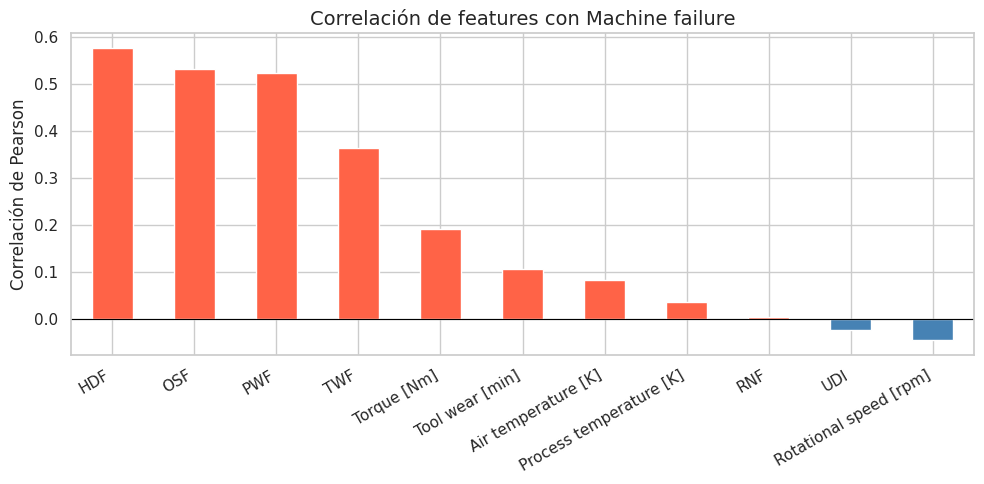

In [10]:
correlacion = (
    df.corr(numeric_only=True)["Machine failure"]
    .drop("Machine failure")
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
correlacion.plot(
    kind="bar",
    ax=ax,
    color=["tomato" if v > 0 else "steelblue" for v in correlacion],
    edgecolor="white",
)
ax.set_title("Correlación de features con Machine failure", fontsize=14)
ax.set_ylabel("Correlación de Pearson")
ax.set_xticklabels(correlacion.index, rotation=30, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Conclusión:** `Torque [Nm]` y `Tool wear [min]` son las features con mayor correlación con la falla. Esto es consistente con el dominio: una herramienta desgastada necesita más torque, lo que estresa la máquina y aumenta la probabilidad de falla.

---

## Resumen ejecutivo

| Pregunta | Hallazgo |
|---|---|
| Tamaño del dataset | 10.000 registros, 14 columnas |
| Valores nulos | Ninguno |
| Desbalance de clases | 96.6% no-falla / 3.4% falla |
| Métrica adecuada | F1-score (no accuracy) |
| Falla más frecuente | Heat Dissipation Failure (HDF) |
| Features más relevantes | Torque y Tool wear |
| Outliers | Presentes en Rotational speed y Torque |